In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import datetime


from src.analytics.aws_function_logs import AWSFunctionLogs
from src.profiler.cost_calculator import CostCalculator
from src.modeling.function_performance_modeling import FunctionPerformanceModeling

In [2]:
payload = '{"bucket_name": "images-test-set", "num_images": 24, "batch_size": 4}'
region_name = 'us-east-1'

memeory_bounds = [(1000, 3008), (1000, 3008), (1000, 3008)]
available_models=["resnet-18", "resnet-34", "resnet-50"]
memory_space_step = 64

function_name = f"sam-ml2-InferenceFunctionResnet2-7yKZyPCdfoHQ"

In [3]:
p_model = FunctionPerformanceModeling(
    function_name=function_name,
    payload=payload,
    memory_bounds=memeory_bounds,
    memory_space_step=memory_space_step,
    profiling_iterations=2,
    available_models=available_models,
)
o_memory = p_model.get_optimal_memory()
print(f"Optimal memory for {function_name} is {o_memory}")
duration_per_memory = {}
for model in available_models:
    duration_per_memory[model] = p_model.get_performance_model_as_function(model_name=model)
del p_model

Explored memories: [1448 1448 1640 1640 2344 2344]
Sample Count:  6
Max Sample Count:  20
Memories:  [1448 1448 1640 1640 2344 2344]
Duration:  [3430. 3457. 2986. 3067. 2815. 2685.]
Value and Threshold:  2.765527002986333 3
Sample Count:  8
Max Sample Count:  20
Memories:  [1448 1448 1640 1640 1960 1960 2344 2344]
Duration:  [3430. 3457. 2986. 3067. 3296. 3338. 2815. 2685.]
Value and Threshold:  1.087351772220144 3
Sample Count:  10
Max Sample Count:  20
Memories:  [1000 1000 1448 1448 1640 1640 1960 1960 2344 2344]
Duration:  [4714. 5011. 3430. 3457. 2986. 3067. 3296. 3338. 2815. 2685.]
Value and Threshold:  2.153556950488475 3
Sample Count:  12
Max Sample Count:  20
Memories:  [1000 1000 1448 1448 1640 1640 1960 1960 2344 2344 2856 2856]
Duration:  [4714. 5011. 3430. 3457. 2986. 3067. 3296. 3338. 2815. 2685. 2043. 2086.]
Value and Threshold:  2.087351772220144 3
Sample Count:  14
Max Sample Count:  20
Memories:  [1000 1000 1064 1064 1448 1448 1640 1640 1960 1960 2344 2344 2856 2856]


In [4]:
aws_logs = AWSFunctionLogs(
    boto_session=boto3.Session(region_name=region_name),
    function_name=function_name,
    docker_deploy=True
)

for model in available_models:
    df = aws_logs.get_logs_df(start_time=int((datetime.datetime.utcnow() - datetime.timedelta(days=1)).timestamp()),
    end_time=int(datetime.datetime.utcnow().timestamp()), model_name=model)

    df.to_csv(f'{function_name}_{model}_logs.csv')

C:\Users\MoeHosseini\AppData\Local\Temp\ipykernel_9760\719281483.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df = aws_logs.get_logs_df(start_time=int((datetime.datetime.utcnow() - datetime.timedelta(days=1)).timestamp()),
C:\Users\MoeHosseini\AppData\Local\Temp\ipykernel_9760\719281483.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time=int(datetime.datetime.utcnow().timestamp()), model_name=model)


In [5]:
cost_calculator = CostCalculator(
    function_name=function_name,
)

In [6]:
dfs = {}
for model in available_models:
    dfs[model] = pd.read_csv(f'{function_name}_{model}_logs.csv')

In [8]:
logs = {}
for model in available_models:
    logs[model] = dfs[model][dfs[model]['Init Duration'].isna()]

    logs[model] = logs[model].groupby('Memory Size').agg({
        'Duration': 'mean',
    }).reset_index()

    if 'Duration' in logs[model].columns and 'Memory Size' in logs[model].columns:
        # Calculate the cost using .loc to avoid SettingWithCopyWarning
        logs[model].loc[:, 'Cost'] = logs[model].apply(
            lambda row: cost_calculator.calculate_cost(
                memory_mb=row['Memory Size'],
                duration_ms=row['Duration']
            ),
            axis=1
        )

In [9]:
modeled_durations = {}
modeled_costs = {}
for i, model in enumerate(available_models):
    memory_bound = memeory_bounds[i]
    memory_space = np.arange(memory_bound[0], memory_bound[1] + 1)

    logs[model] = logs[model][logs[model]['Memory Size'].isin(memory_space)]

    modeled_duration = []
    modeled_cost = []

    for memory in memory_space:
        t = duration_per_memory[model](memory)
        modeled_duration.append(t)
        modeled_cost.append(cost_calculator.calculate_cost(memory_mb=memory, duration_ms=t))

    modeled_duration = np.array(modeled_duration)
    modeled_cost = np.array(modeled_cost)
    modeled_durations[model] = modeled_duration
    modeled_costs[model] = modeled_cost

In [10]:
logs

{'resnet-18':     Memory Size     Duration      Cost
 0        1000.0  7296.754459  0.000119
 1        1064.0  6229.299690  0.000108
 2        1128.0  8293.903000  0.000152
 3        1192.0  8004.637000  0.000156
 4        1448.0  5181.839318  0.000122
 5        1640.0  5013.320093  0.000134
 6        1896.0  5184.377000  0.000160
 7        1960.0  4065.803000  0.000130
 8        2024.0  4053.352970  0.000134
 9        2344.0  6498.786938  0.000248
 10       2536.0  3885.215000  0.000161
 11       2600.0  2614.866667  0.000111
 12       2664.0  3106.225400  0.000135
 13       2728.0  4275.055143  0.000190
 14       2856.0  2931.834143  0.000136
 15       2920.0  2789.679480  0.000133
 16       2984.0  3476.172833  0.000169,
 'resnet-34':     Memory Size     Duration      Cost
 0        1000.0  7296.754459  0.000119
 1        1064.0  6229.299690  0.000108
 2        1128.0  8293.903000  0.000152
 3        1192.0  8004.637000  0.000156
 4        1448.0  5181.839318  0.000122
 5        164

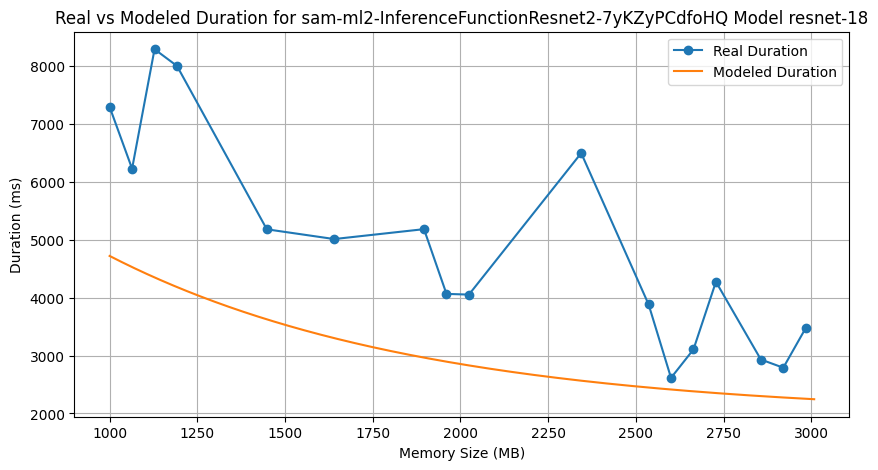

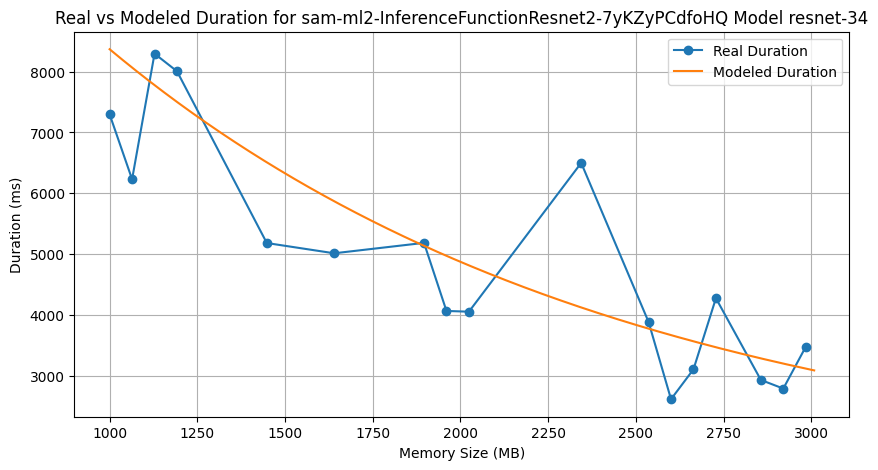

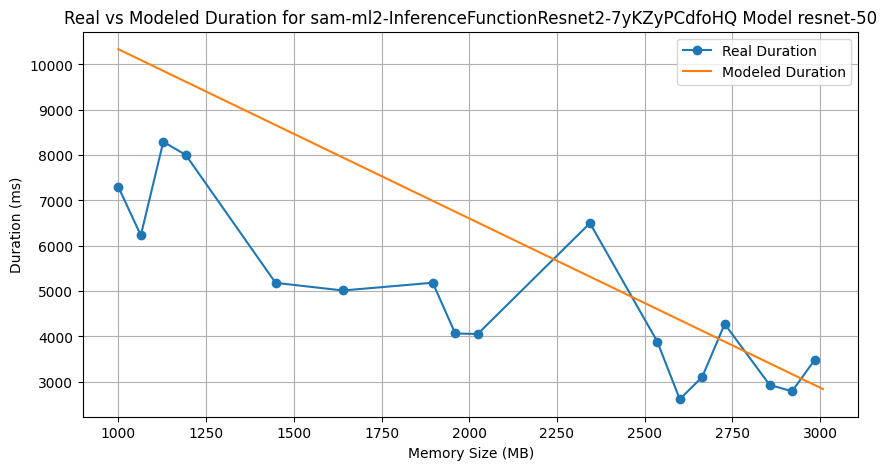

In [11]:
for model in available_models:
    modeled_duration = modeled_durations[model]
    memory_bound = memeory_bounds[i]
    memory_space = np.arange(memory_bound[0], memory_bound[1] + 1)
    
    plt.figure(figsize=(10, 5))
    plt.plot(logs[model]['Memory Size'], logs[model]['Duration'], label='Real Duration', marker='o')
    plt.plot(memory_space, modeled_duration, label='Modeled Duration')
    plt.xlabel('Memory Size (MB)')
    plt.ylabel('Duration (ms)')
    plt.title(f'Real vs Modeled Duration for {function_name} Model {model}')
    plt.legend()
    plt.grid()

    plt.show()